# Phase 2 - Supervised Learning

## Project Title

Medical Insurance Cost Risk and Advice System

## Goal

The goal of this notebook is to build supervised machine learning models that predict the user's insurance cost-risk advice class.

The original column `charges` is continuous, so we convert it into three advice classes:

- Low Cost Risk
- Medium Cost Risk
- High Cost Risk

This makes the model more suitable for an advice system.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")


In [2]:
# Load dataset
df = pd.read_csv("Dataset/insurance.csv")
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:

# Basic cleaning
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows before removal: 1
Shape after duplicate removal: (1337, 7)


## Target for Supervised Learning

The original target is `charges`, which is a number. For the advice system, we create `risk_level` by dividing charges into three groups.

This gives the model a clear advice class to predict.


Risk level distribution:
risk_level
Low Cost Risk       446
Medium Cost Risk    445
High Cost Risk      446
Name: count, dtype: int64


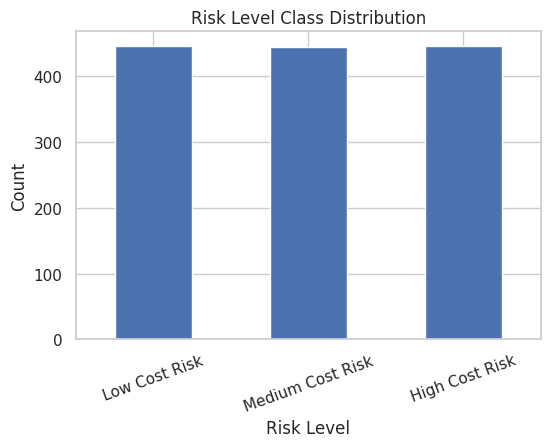

In [4]:

# Create advice classes from charges
risk_names = ["Low Cost Risk", "Medium Cost Risk", "High Cost Risk"]

df["risk_level"] = pd.qcut(
    df["charges"],
    q=3,
    labels=risk_names
)

print("Risk level distribution:")
print(df["risk_level"].value_counts().reindex(risk_names))

plt.figure(figsize=(6, 4))
df["risk_level"].value_counts().reindex(risk_names).plot(kind="bar")
plt.title("Risk Level Class Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


## Algorithm Selection

We selected three supervised models:

1. Logistic Regression: a simple baseline model.
2. Random Forest: useful for non-linear relations and mixed features.
3. SVM: useful when the decision boundary is not linear.

We compare them using the same train-test split and the same evaluation metrics.


In [5]:

# Prepare features and target
features = ["age", "sex", "bmi", "children", "smoker", "region"]
X = df[features]

y = df["risk_level"].astype(str).map({name: i for i, name in enumerate(risk_names)})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (1069, 6)
Testing shape: (268, 6)


In [6]:

# Train and compare models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
}

results = []
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(y_test, y_pred, average="macro"),
        "Recall Macro": recall_score(y_test, y_pred, average="macro"),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "ROC-AUC Macro": roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"),
        "CV F1 Mean": cv_f1.mean(),
        "CV F1 Std": cv_f1.std()
    })

    trained_models[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by="F1 Macro", ascending=False)
display(results_df.round(4))

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best model based on F1 Macro:", best_model_name)


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC Macro,CV F1 Mean,CV F1 Std
2,SVM,0.9030,0.9098,0.9026,0.8999,0.9495,0.8738,0.0069
1,Random Forest,0.8918,0.8941,0.8914,0.8900,0.9531,0.8857,0.0155
0,Logistic Regression,0.8470,0.8777,0.8467,0.8410,0.9275,0.8389,0.0091


Best model based on F1 Macro: SVM


Classification report for: SVM
                  precision    recall  f1-score   support

   Low Cost Risk       0.89      1.00      0.94        90
Medium Cost Risk       0.87      0.96      0.91        89
  High Cost Risk       0.97      0.75      0.85        89

        accuracy                           0.90       268
       macro avg       0.91      0.90      0.90       268
    weighted avg       0.91      0.90      0.90       268



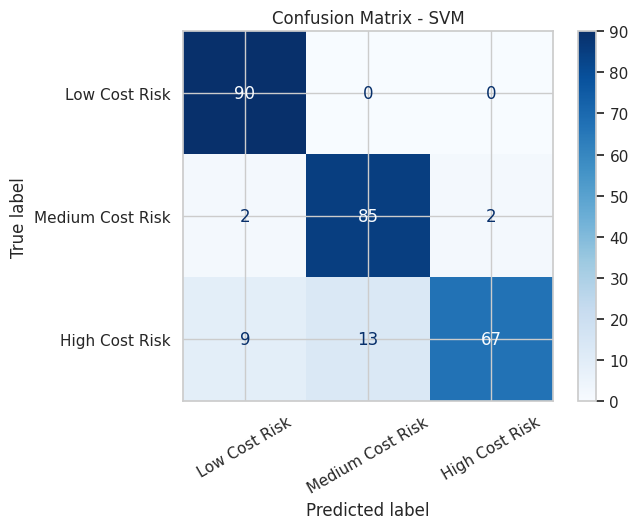

In [7]:

# Detailed report for the best model
y_best_pred = best_model.predict(X_test)

print("Classification report for:", best_model_name)
print(classification_report(y_test, y_best_pred, target_names=risk_names))

cm = confusion_matrix(y_test, y_best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=risk_names)
disp.plot(cmap="Blues", xticks_rotation=30)
plt.title("Confusion Matrix - " + best_model_name)
plt.show()


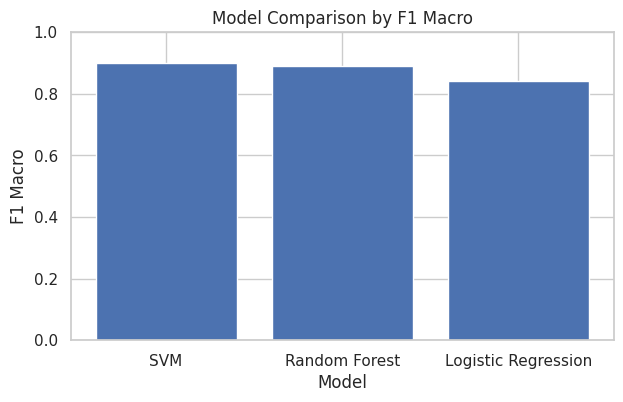

In [8]:

# Compare model scores visually
plt.figure(figsize=(7, 4))
plt.bar(results_df["Model"], results_df["F1 Macro"])
plt.title("Model Comparison by F1 Macro")
plt.xlabel("Model")
plt.ylabel("F1 Macro")
plt.ylim(0, 1)
plt.show()


Top feature importances from Random Forest:


,Feature,Importance
0,num__age,0.486856
6,cat__smoker_yes,0.140731
1,num__bmi,0.138798
5,cat__smoker_no,0.137782
2,num__children,0.052206
7,cat__region_northeast,0.008820
9,cat__region_southeast,0.007908
8,cat__region_northwest,0.007529
3,cat__sex_female,0.006748
10,cat__region_southwest,0.006531


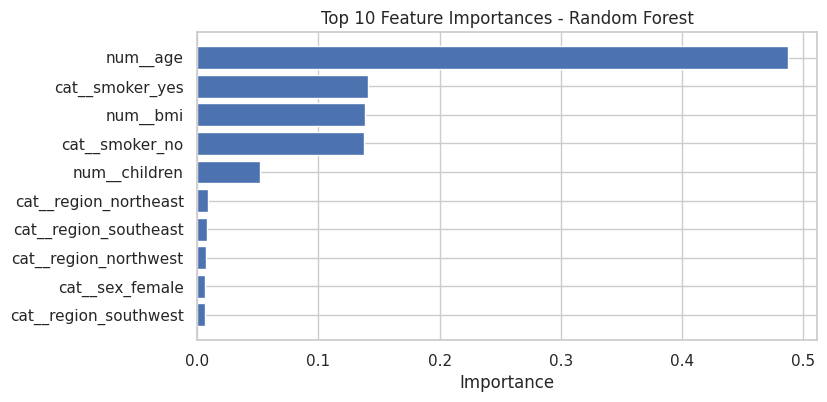

In [9]:

# Feature importance for Random Forest
# This helps us understand which features affected the prediction.

rf_pipe = trained_models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top feature importances from Random Forest:")
display(importance_df.head(10))

plt.figure(figsize=(8, 4))
plt.barh(importance_df.head(10)["Feature"], importance_df.head(10)["Importance"])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


## Prediction Example

This part shows how the final system can receive user input and return an advice class.

The advice is general and based on the predicted insurance cost-risk level.


In [10]:

# Example user input
sample_user = pd.DataFrame({
    "age": [32],
    "sex": ["male"],
    "bmi": [29.5],
    "children": [1],
    "smoker": ["no"],
    "region": ["northwest"]
})

pred_num = best_model.predict(sample_user)[0]
pred_label = risk_names[pred_num]
probs = best_model.predict_proba(sample_user)[0]

print("Sample user:")
display(sample_user)

print("Predicted advice class:", pred_label)
print("Prediction probabilities:")
for name, prob in zip(risk_names, probs):
    print(name + ":", round(prob, 3))


def give_advice(label):
    if label == "Low Cost Risk":
        return "The user is predicted to have low insurance cost risk compared with the dataset."
    elif label == "Medium Cost Risk":
        return "The user is predicted to have a medium insurance cost risk."
    else:
        return "The user is predicted to have high insurance cost risk. Major factors should be reviewed."

print("\nAdvice:")
print(give_advice(pred_label))


Sample user:


,age,sex,bmi,children,smoker,region
0,32,male,29.5,1,no,northwest


Predicted advice class: Low Cost Risk
Prediction probabilities:
Low Cost Risk: 0.932
Medium Cost Risk: 0.017
High Cost Risk: 0.051

Advice:
The user is predicted to have low insurance cost risk compared with the dataset.


## Results Interpretation

The best model is selected using F1 Macro because the target has three classes and we want balanced performance across all classes.

From the comparison table, the best model is the one with the highest F1 Macro score.

Random Forest is also useful because it can capture non-linear relationships between age, BMI, smoking status, and insurance cost risk.

The feature importance chart helps explain the model. Important features are expected to include smoking status, age, and BMI.

The prediction example shows how the model can be used as an advice system. The user enters basic information, and the model returns a cost-risk class with a simple advice message.
